2026-03-26 08:35:46.655452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774514146.919698      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774514146.997513      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774514147.557823      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774514147.557877      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774514147.557881      55 computation_placer.cc:177] computation placer alr

Total patients: 281
Indexing volumes for Training...
Indexing volumes for Testing...


2026-03-26 08:38:44.718733: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Training 3D DenseNet...
Epoch 1/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.6461 - auc: 0.7216 - loss: 0.6146 - val_accuracy: 0.5088 - val_auc: 0.8894 - val_loss: 0.6729
Epoch 2/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 135s 604ms/step - accuracy: 0.7194 - auc: 0.7769 - loss: 0.5639 - val_accuracy: 0.8772 - val_auc: 0.9364 - val_loss: 0.4146
Epoch 3/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 132s 589ms/step - accuracy: 0.7751 - auc: 0.8456 - loss: 0.4869 - val_accuracy: 0.8860 - val_auc: 0.9657 - val_loss: 0.3466
Epoch 4/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 194s 867ms/step - accuracy: 0.8034 - auc: 0.8273 - loss: 0.4718 - val_accuracy: 0.9035 - val_auc: 0.9625 - val_loss: 0.2940
Epoch 5/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 147s 655ms/step - accuracy: 0.7621 - auc: 0.8421 - loss: 0.4711 - val_accuracy: 0.8772 - val_auc: 0.9564 - val_loss: 0.2818


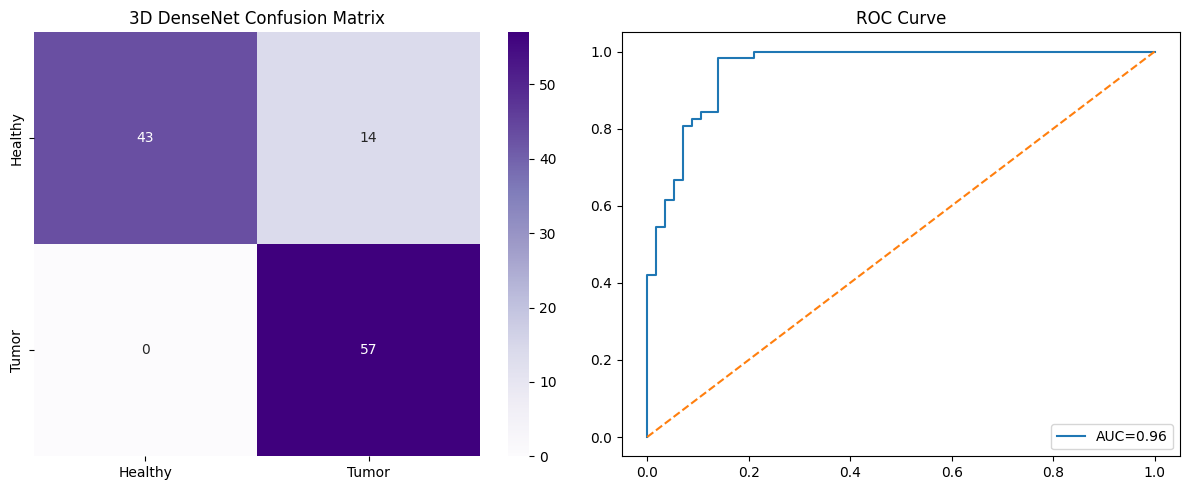

              precision    recall  f1-score   support

         0.0       1.00      0.75      0.86        57
         1.0       0.80      1.00      0.89        57

    accuracy                           0.88       114
   macro avg       0.90      0.88      0.88       114
weighted avg       0.90      0.88      0.88       114

AUC: 0.9560


In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv3D, GlobalAveragePooling3D, Dense, Dropout, BatchNormalization, Activation, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. CONFIGURATION ---
PATCH_SIZE = 64
BATCH_SIZE = 2   # keep small for 3D DenseNet memory
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# --- 2. DATA SEQUENCE ---
class Pancreas3DPatchSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE, is_training=True):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.is_training = is_training
        self.samples = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        print(f"Indexing volumes for {'Training' if self.is_training else 'Testing'}...")
        for file in self.patient_files:
            if file.startswith("._"): continue
            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path): continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2)

            if len(tumor_indices) > 0:
                rand_idx = np.random.randint(len(tumor_indices))
                tumor_center = tumor_indices[rand_idx]
                samples.append((file, tumor_center, 1))

                # Random healthy point
                h, w, d = mask_vol.shape
                while True:
                    rand_point = [np.random.randint(0,h), np.random.randint(0,w), np.random.randint(0,d)]
                    if mask_vol[tuple(rand_point)] == 0:
                        break
                samples.append((file, rand_point, 0))

        np.random.shuffle(samples)
        return samples

    def __len__(self):
        return int(np.ceil(len(self.samples)/self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for file, center, label in batch:
            img_vol = nib.load(os.path.join(IMAGE_DIR,file)).get_fdata()
            z,y_c,x = [int(c) for c in center]

            z_s, y_s, x_s = max(0,z-32), max(0,y_c-32), max(0,x-32)
            patch = img_vol[z_s:z_s+PATCH_SIZE, y_s:y_s+PATCH_SIZE, x_s:x_s+PATCH_SIZE]

            if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                patch = np.pad(patch, [(0, PATCH_SIZE-p) for p in patch.shape], mode='constant')

            patch = np.clip(patch, -100, 200)
            patch = (patch + 100)/300.0

            X.append(patch[..., np.newaxis])
            y.append(label)
        return np.array(X,dtype='float32'), np.array(y,dtype='float32')

# --- 3. 3D DenseNet Model ---
def build_3d_densenet():
    inputs = Input((PATCH_SIZE,PATCH_SIZE,PATCH_SIZE,1))
    x = Conv3D(16,3,strides=2,padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    for _ in range(2):
        shortcut = x
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv3D(16,3,padding='same')(x)
        x = Concatenate()([x, shortcut])

    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1,activation='sigmoid')(x)

    model = Model(inputs,outputs)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# --- 4. LOAD FILES ---
all_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith((".nii",".nii.gz")) and not f.startswith(".")])
print(f"Total patients: {len(all_files)}")
train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)

train_seq = Pancreas3DPatchSequence(train_f)
test_seq = Pancreas3DPatchSequence(test_f, is_training=False)

# --- 5. TRAIN ---
model_dense = build_3d_densenet()
print("Training 3D DenseNet...")
model_dense.fit(train_seq, validation_data=test_seq, epochs=5)

# --- 6. EVALUATION ---
y_true, y_probs = [], []
for i in range(len(test_seq)):
    xb, yb = test_seq[i]
    preds = model_dense.predict(xb, verbose=0)
    y_true.extend(yb)
    y_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs>0.5).astype(int)

# --- 7. PLOTS ---
fpr, tpr, _ = roc_curve(y_true,y_probs)
roc_auc = auc(fpr,tpr)
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy','Tumor'], yticklabels=['Healthy','Tumor'])
plt.title('3D DenseNet Confusion Matrix')

plt.subplot(1,2,2)
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title('ROC Curve')
plt.tight_layout()
plt.show()

print(classification_report(y_true,y_pred))
print(f"AUC: {roc_auc:.4f}")